In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import math
from iminuit import Minuit, cost
from scipy import stats

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["savefig.bbox"]='tight'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

In [ ]:
def hypergeom_3binom(N, K, n, k):
    """likelyhood function"""

    comb1 = math.comb(K,k)
    comb2 = math.comb(N - K, n - k)
    comb3 = math.comb(N, n)
    prob = comb1 * comb2 / comb3
    return prob



def prior(N):
    return 1/N

maximum for k=10 with prior 1 is at N=599
maximum for k=10 with prior 1/N is at N=559
maximum for k=15 with prior 1 is at N=399
maximum for k=15 with prior 1/N is at N=384


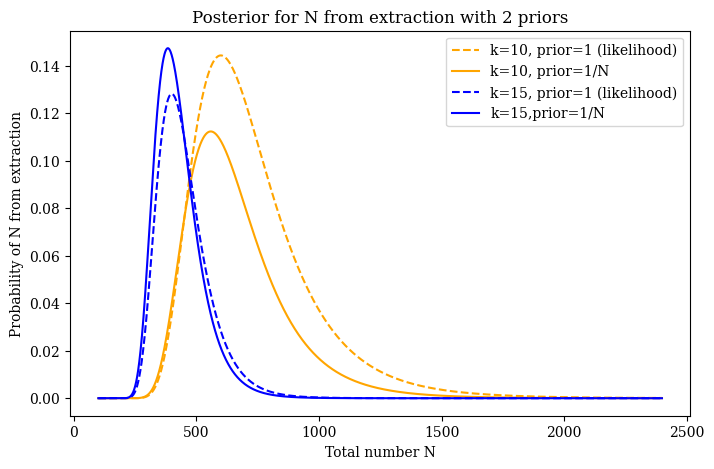

In [23]:
n=60
K=100
k=10

N_max=2400
scaling_factor=450

N_array=np.arange(100,N_max,1)
prob_array=[]
for N in N_array:
    prob=hypergeom_3binom(N, K, n, k)*prior(1)
    prob_array.append(prob)


fig1,ax1=plt.subplots(figsize=(8,5))
ax1.plot(N_array, prob_array,label=f"k={k}, prior=1 (likelihood)", color='orange', linestyle='--')
ax1.set_xlabel('Total number N')
ax1.set_ylabel('Probability of N from extraction')
ax1.set_title('Posterior for N from extraction with 2 priors')
print(f"maximum for k={k} with prior 1 is at N={N_array[np.argmax(prob_array)]}")



N_array=np.arange(100,N_max,1)
prob_array=[]
for N in N_array:
    prob=hypergeom_3binom(N, K, n, k)*prior(N)*scaling_factor
    prob_array.append(prob)

ax1.plot(N_array, prob_array,label=f"k={k}, prior=1/N", color='orange')
print(f"maximum for k={k} with prior 1/N is at N={N_array[np.argmax(prob_array)]}")




n=60
K=100
k=15

N_array=np.arange(100,N_max,1)
prob_array=[]
for N in N_array:
    prob=hypergeom_3binom(N, K, n, k)*prior(1)
    prob_array.append(prob)

ax1.plot(N_array, prob_array,label=f"k={k}, prior=1 (likelihood)",color='blue',linestyle='--')
print(f"maximum for k={k} with prior 1 is at N={N_array[np.argmax(prob_array)]}")



N_array=np.arange(100,N_max,1)
prob_array=[]
for N in N_array:
    prob=hypergeom_3binom(N, K, n, k)*prior(N)*scaling_factor
    prob_array.append(prob)

ax1.plot(N_array, prob_array,label=f"k={k},prior=1/N", color='blue')
print(f"maximum for k={k} with prior 1/N is at N={N_array[np.argmax(prob_array)]}")
ax1.legend()

In [42]:
lake_samples=r.normal(loc=5000, scale=300, size=10000)
space_samples=r.normal(loc=10, scale=1, size=10000)
print(f"mean lake={np.mean(lake_samples)},std={np.std(lake_samples)}, mean space={np.mean(space_samples)},std={np.std(space_samples)}")

mean lake=4995.121083635272,std=301.192684213051, mean space=10.018836604091035,std=1.0018321110053832


In [43]:
N_samples=np.zeros((len(lake_samples),len(space_samples)))
for i in range(len(lake_samples)):
    for j in range(len(space_samples)):
        N_samples[i,j]=lake_samples[i]/space_samples[j]

estimated_N=np.mean(N_samples)
estimated_scale=np.std(N_samples)
print(f"mean N={estimated_N}, std N={estimated_scale}")

mean N=503.7198604032502, std N=60.341089635339124


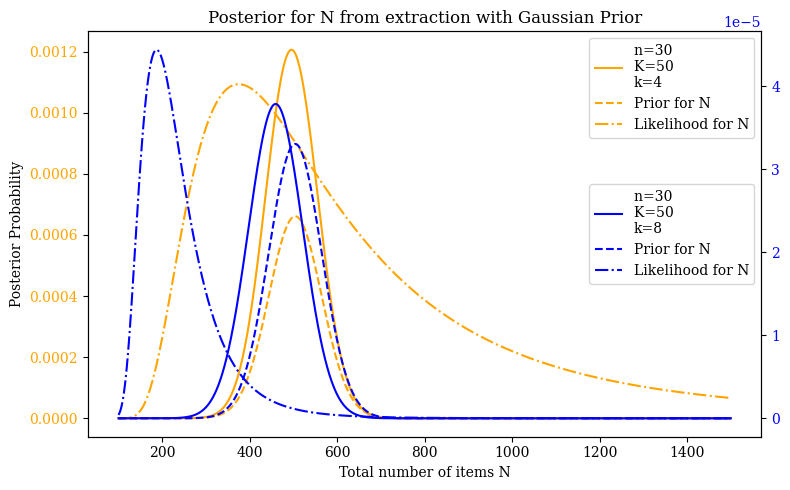

In [68]:
n=30
K=50
k=4


N_array=np.arange(100,1500,1)
prob_array=[]
prior_array=[]
lh_array=[]
for N in N_array:
    prior=stats.norm.pdf(N, loc=estimated_N, scale=estimated_scale)
    prior_array.append(prior*0.1)
    lh=hypergeom_3binom(N, K, n, k)
    lh_array.append(lh/200)
    prob=lh*prior
    prob_array.append(prob)


fig2,ax2=plt.subplots(figsize=(8,5))
c='orange'
ax2.plot(N_array, prob_array,label=f"n={n} \nK={K} \nk={k}", color=c)
ax2.plot(N_array, prior_array,label=f"Prior for N", color=c, linestyle='--')
ax2.plot(N_array, lh_array,label=f"Likelihood for N", color=c, linestyle='-.')
ax2.tick_params(axis='y', labelcolor=c)




k=8

N_array=np.arange(100,1500,1)
prob_array=[]
prior_array=[]
lh_array=[]
for N in N_array:
    prior=stats.norm.pdf(N, loc=estimated_N, scale=estimated_scale)
    prior_array.append(prior/200)
    lh=hypergeom_3binom(N, K, n, k)
    lh_array.append(lh/4000)
    prob=lh*prior
    prob_array.append(prob)

c='blue'
ax3=ax2.twinx()  # instantiate a second Axes that shares the same x-axis
ax3.plot(N_array, prob_array,label=f"n={n} \nK={K} \nk={k}", color=c)
ax3.plot(N_array, prior_array,label=f"Prior for N", color=c, linestyle='--')
ax3.plot(N_array, lh_array,label=f"Likelihood for N", color=c, linestyle='-.')
ax3.tick_params(axis='y', labelcolor=c)

ax2.set_xlabel('Total number of items N')
ax2.set_ylabel('Posterior Probability')
ax2.set_title('Posterior for N from extraction with Gaussian Prior')
ax2.legend(loc='upper right')
ax3.legend(loc='center right')

fig2.tight_layout()

maximum for k=12 with Gaussian prior is at N=415
Probability of N being greater than 409 is 10.827950844857986


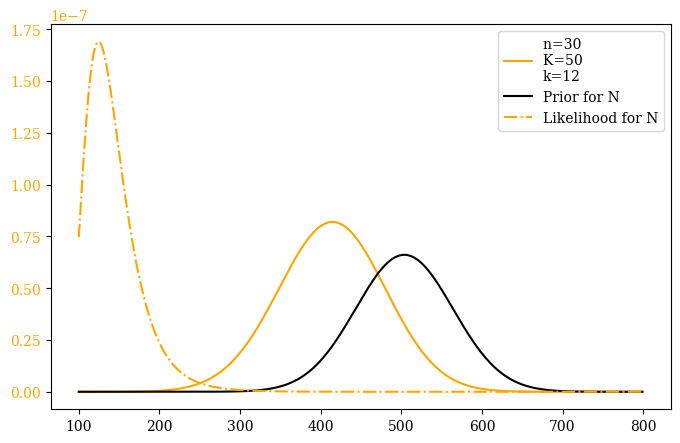

In [ ]:
k=12


N_array=np.arange(100,800,1)
prob_array=[]
prior_array=[]
lh_array=[]
for N in N_array:
    prior=stats.norm.pdf(N, loc=estimated_N, scale=estimated_scale)
    prior_array.append(prior/100000)
    lh=hypergeom_3binom(N, K, n, k)
    lh_array.append(lh)
    prob=lh*prior
    prob_array.append(prob)

print(f"maximum for k={k} with Gaussian prior is at N={N_array[np.argmax(prob_array)]}")

fig4,ax4=plt.subplots(figsize=(8,5))
c='orange'
ax4.plot(N_array, prob_array,label=f"n={n} \nK={K} \nk={k}", color=c)
ax4.plot(N_array, prior_array,label=f"Prior for N", color='black', linestyle='solid')
ax4.plot(N_array, [lh/1000000 for lh in lh_array],label=f"Likelihood for N", color=c, linestyle='-.')
ax4.tick_params(axis='y', labelcolor=c)
ax4.legend(loc='upper right')

#integrate the tail of the distribution to find the probability of N being above a certain value
N_or_greater=409
integral=np.trapezoid(lh_array,N_array)
#[N_array], N_array[N_array>=N_or_greater])
print(f"Probability of N being greater than {N_or_greater} is {integral}")